Birds inspired us to fly, nature inspired us to countless inventions. It seems logical, then to look at the brain’s architecture for inspiration on how to build an Intelligent Machine. This is the logic that sparked Artificial Neural Networks (ANN). ANN is a Machine Learning Model inspired by the networks of biological neurons found in our brains. However, although planes were inspired by birds, they don’t have to flap their wings. Similarly, ANN have gradually become quite different from their biological cousins. In this Article, I will build an Image Classification model with ANN to show you how ANN works.

In [1]:
import sys
# assert sys.version_info >= (3, 5) # This line caused a SyntaxError

# To address the SyntaxError encountered with the tuple comparison,
# which is typically valid Python 3 syntax, we will use an alternative
# explicit version check.
if sys.version_info < (3, 5):
    raise RuntimeError("This notebook requires Python 3.5 or later.")

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


## Using Keras to Load the Dataset
Keras provide some quality functions to fetch and load common datasets, including MNIST, Fashion MNIST, and the California housing dataset. Let’s start by loading the fashion MNIST dataset to create an Image Classification model.

Keras has a number of functions to load popular datasets in keras.datasets. The dataset is already split for you between a training set and a test set, but it can be useful to split the training set further to have a validation set:

In [2]:
import tensorflow as tf
from tensorflow import keras
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train_full.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
X_train_full.dtype

dtype('uint8')

In [6]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

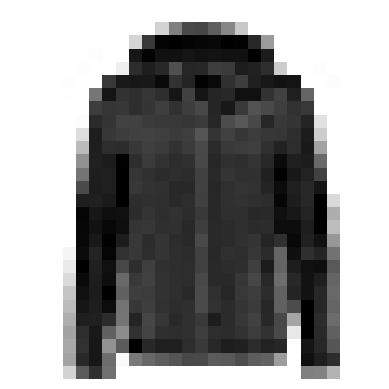

In [7]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

In [8]:
y_train

array([4, 0, 7, ..., 3, 0, 5], dtype=uint8)

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [10]:
class_names[y_train[0]]

'Coat'

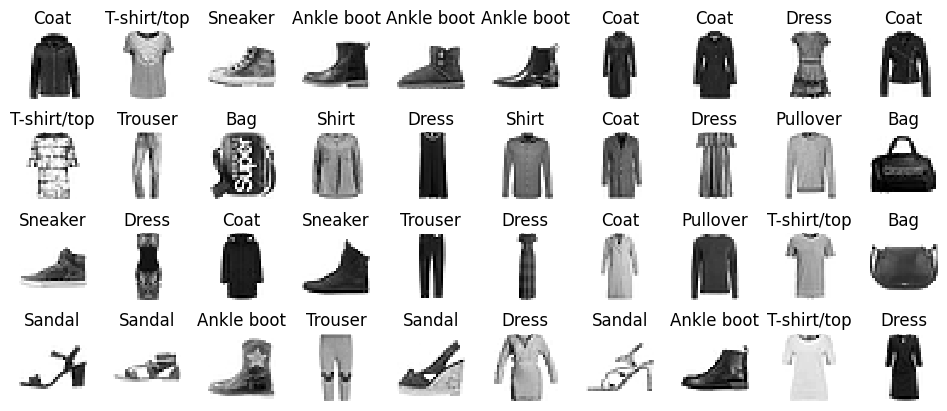

In [11]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
# save_fig('fashion_mnist_plot', tight_layout=False) # This function is not defined
plt.show()

Image Classification Model using Sequential API

In [12]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

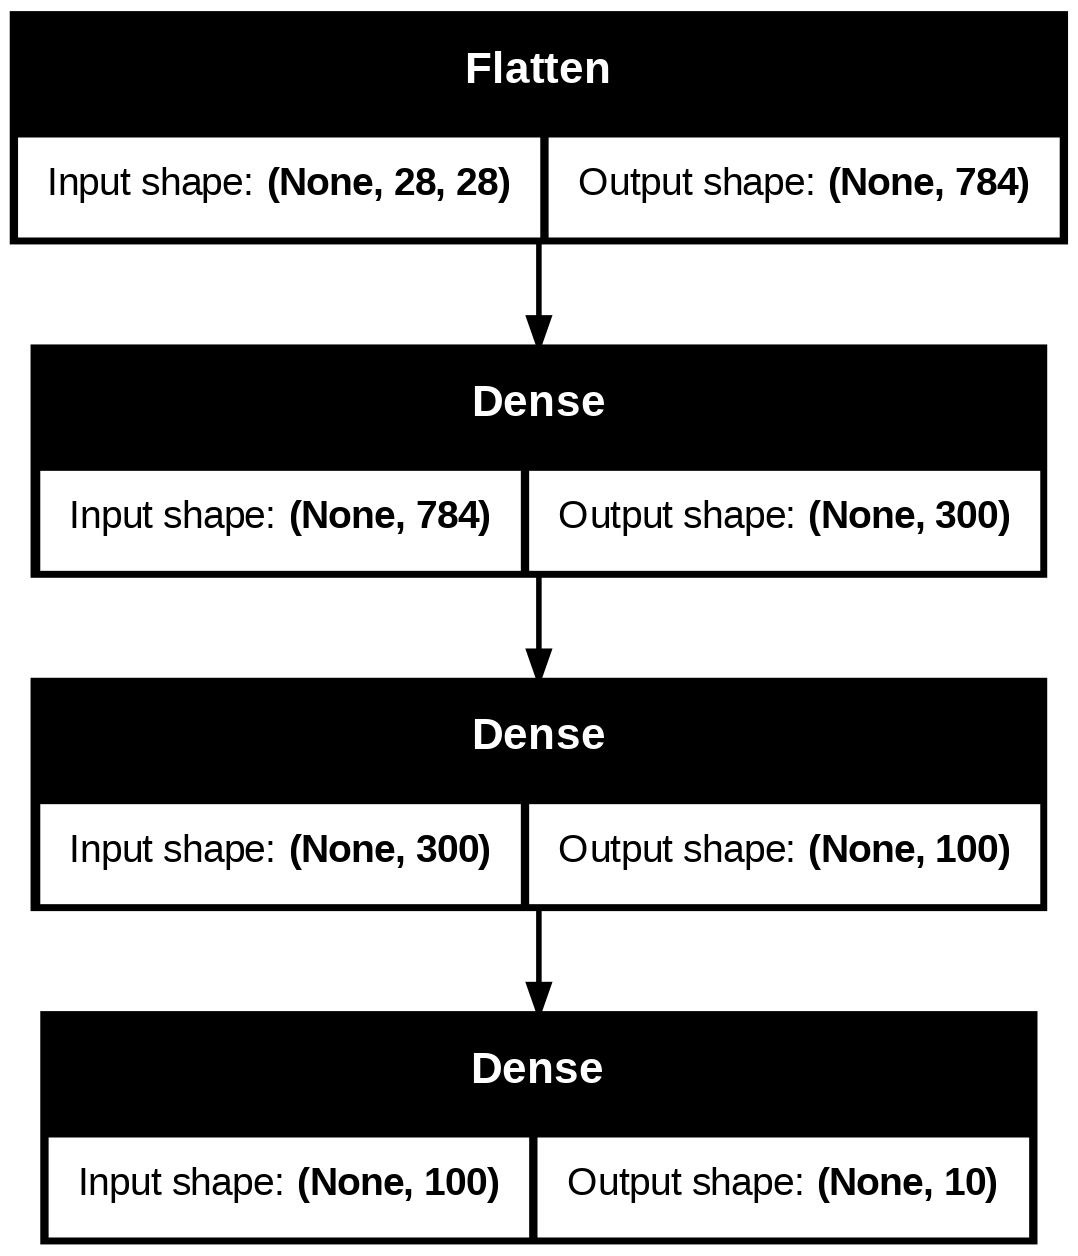

In [15]:
keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

In [16]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [17]:
model.get_layer(hidden1.name) is hidden1


True

In [18]:
weights, biases = hidden1.get_weights()


In [19]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [20]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6812 - loss: 1.0034 - val_accuracy: 0.8194 - val_loss: 0.5262
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8238 - loss: 0.5059 - val_accuracy: 0.8454 - val_loss: 0.4576
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8414 - loss: 0.4509 - val_accuracy: 0.8552 - val_loss: 0.4244
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8504 - loss: 0.4205 - val_accuracy: 0.8626 - val_loss: 0.4020
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8582 - loss: 0.3988 - val_accuracy: 0.8670 - val_loss: 0.3866
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8643 - loss: 0.3818 - val_accuracy: 0.8700 - val_loss: 0.3746
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8692 - loss: 0.3679 - val_accuracy: 0.8718 - val_loss: 0.3650
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8737 - loss: 0.3560 - 

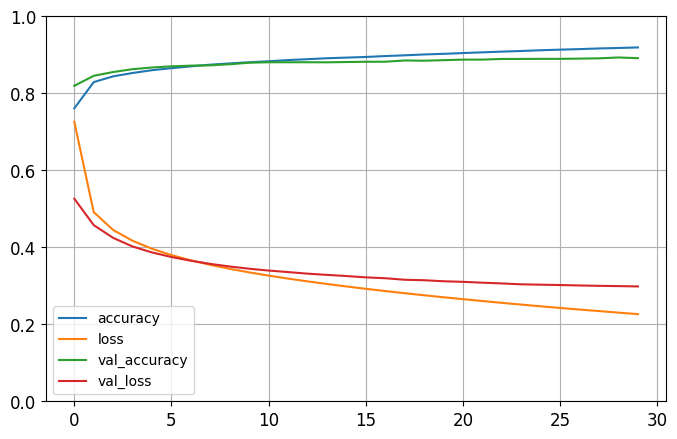

In [22]:
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)

plt.show()

### Saving the Keras Model

First, save your trained Keras model. You can save it in the native Keras format, which is generally recommended.

In [23]:
model.save('my_fashion_mnist_model.keras')
print('Model saved as my_fashion_mnist_model.keras')

Model saved as my_fashion_mnist_model.keras


### Preparing for Hugging Face Spaces

To use this model in Hugging Face Spaces, you typically need to:

1.  **Create a new Hugging Face Space**: Go to [huggingface.co/spaces/new](https://huggingface.co/spaces/new) and create a new Space. Choose a framework like Keras/TensorFlow.

2.  **Upload your model file**: You can upload the `my_fashion_mnist_model.keras` file directly to your Space's repository. In your Space's page on Hugging Face, go to the "Files" tab and click "Add file" to upload it.

3.  **Create an `app.py` or `main.py` file**: This Python file will contain the code to load your model and define the inference logic. A simple `app.py` for a Keras model might look like this (using `gradio` for the UI):

    ```python
    import tensorflow as tf
    from tensorflow import keras
    import numpy as np
    import gradio as gr

    # Define your class names (make sure this matches your training data)
    class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                   "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

    # Load the trained model
    model = keras.models.load_model('my_fashion_mnist_model.keras')

    def predict_image(image):
        # Preprocess the image
        img = image.astype('float32') / 255.0 # Scale to 0-1 range
        img = np.expand_dims(img, axis=0)  # Add batch dimension
        
        # Make prediction
        predictions = model.predict(img)[0]
        
        # Get predicted class and probabilities
        predicted_class_idx = np.argmax(predictions)
        predicted_class_name = class_names[predicted_class_idx]
        
        # Return probabilities as a dictionary for Gradio
        return {name: float(prob) for name, prob in zip(class_names, predictions)}

    # Create a Gradio interface
    iface = gr.Interface(
        fn=predict_image,
        inputs=gr.Image(shape=(28, 28), image_mode='L', invert_colors=True, source='canvas'), # 'L' for grayscale
        outputs=gr.Label(num_top_classes=3),
        title="Fashion MNIST Image Classifier",
        description="Upload a 28x28 grayscale image of a fashion item and get predictions."
    )

    iface.launch()
    ```

4.  **Create a `requirements.txt` file**: List all Python dependencies your `app.py` needs, e.g.:

    ```
    tensorflow
    numpy
    gradio
    ```

5.  **Commit these files**: Push `my_fashion_mnist_model.keras`, `app.py`, and `requirements.txt` to your Hugging Face Space's Git repository. The Space will then automatically build and deploy your application.